# Autoencoder MNIST

## Importing required packages

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from  torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim
from torchvision import datasets,transforms

## Defining transforms

In [4]:
transforms=transforms.ToTensor()

## Downloading requried data

In [5]:
train_data=datasets.MNIST('data',train=True,download=True,transform=transforms)
test_data=datasets.MNIST('data',train=False,download=True,transform=transforms)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.9MB/s]


## Defining dataloaders

In [6]:
valid_size=0.2

# IMPORTANT
batch_size=20

num_workers=0

train_length = len(train_data)

# obtain training dataset indices that will be used for validation dataset
indices = list(range(train_length))

np.random.shuffle(indices)
split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders for train, test and validation dataset
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
    num_workers=num_workers)

In [7]:

# Printing the length of our train, valid and test dataloaders
# NOTE : Here batch size is 20
len(train_loader),len(valid_loader),len(test_loader)

(2400, 600, 500)

In [8]:
# checking our data
dataiter = iter(train_loader)
images, labels = next(dataiter)
print(images, images.shape, len(images), images[0].shape)
print()
print(labels, labels.shape, len(labels))

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0.

## Visualizing a Training batch

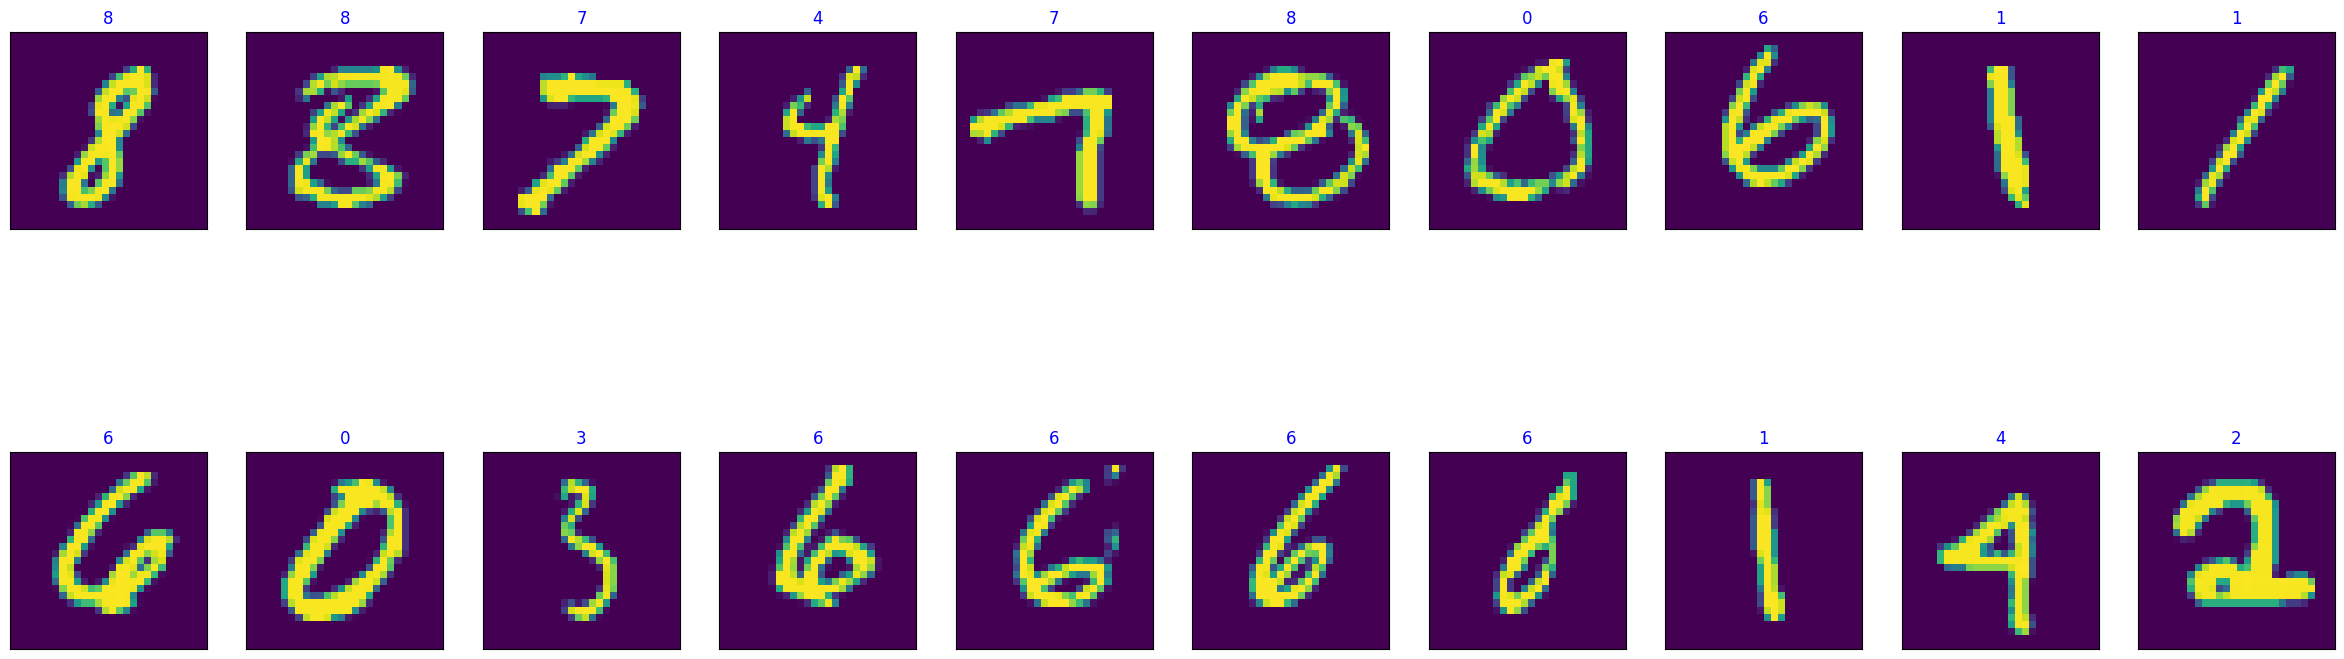

In [9]:
# Displaying images and labels of a batch
fig=plt.figure(figsize=(30,10))
for i in range(len(labels)):
    ax=fig.add_subplot(2,10,i+1,xticks=[],yticks=[])
    plt.imshow(np.squeeze(images[i]))
    ax.set_title(labels[i].item(),color='blue')

## Defining Architecture

In [10]:
class F_Auto_MNIST(nn.Module):
    def __init__(self,en_dim):
        super(F_Auto_MNIST,self).__init__()
        self.encoder=nn.Linear(784,en_dim)
        self.decoder=nn.Linear(en_dim,784)

    def forward(self,x):
        x=F.relu(self.encoder(x))
        x=F.sigmoid(self.decoder(x))
        return x

class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(Tran_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.ConvTranspose2d(4,16,2,stride=2)
        self.de_conv2=nn.ConvTranspose2d(16,1,2,stride=2)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x=F.relu(self.de_conv1(x))
        x=F.sigmoid(self.de_conv2(x))
        return x

class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(upsamp_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.Conv2d(4,16,3,padding=1)
        self.de_conv2=nn.Conv2d(16,1,3,padding=1)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x = F.upsample(x, scale_factor=2, mode='nearest')
        x=F.relu(self.de_conv1(x))
        x = F.upsample(x, scale_factor=2, mode='nearest')
        x=F.sigmoid(self.de_conv2(x))
        return x

#Since the images are normalized between 0 and 1, we need to use a sigmoid activation on the output layer to get values that match this input value range.

In [11]:
model_1=F_Auto_MNIST(32)
model_2=Tran_conv_Auto_MNIST()
model_3=upsamp_conv_Auto_MNIST()

def weight_init_normal(m):
    classname=m.__class__.__name__
    if classname.find('Linear')!=-1:
        n = m.in_features
        y = (1.0/np.sqrt(n))
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model_1.apply(weight_init_normal)

use_cuda=True
if use_cuda and torch.cuda.is_available():
  model_1.cuda()
  model_2.cuda()
  model_3.cuda()
print(model_1,'\n\n\n\n',model_2,'\n\n\n\n',model_3,'\n\n\n\n','On GPU : ',torch.cuda.is_available())

F_Auto_MNIST(
  (encoder): Linear(in_features=784, out_features=32, bias=True)
  (decoder): Linear(in_features=32, out_features=784, bias=True)
) 



 Tran_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (de_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
) 



 upsamp_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (de_conv2): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
) 



 O

## Defining our Loss Function

In [12]:
# Used when comapring pixel values.
criterion=nn.MSELoss()

## Training and Validation Phase

In [13]:
def trainNet(model,lr,state='fully'):
    optimizer=torch.optim.Adam(model.parameters(),lr=lr)

    # Number of epochs to train for
    loss_keeper={'train':[],'valid':[]}
    epochs=20

    # minimum validation loss ----- set initial minimum to infinity
    valid_loss_min = np.inf

    for epoch in range(epochs):
        train_loss=0.0
        valid_loss=0.0

        """
        TRAINING PHASE
        """
        model.train() # TURN ON DROPOUT for training
        for images,_ in train_loader:
            if use_cuda and torch.cuda.is_available():
                images=images.cuda()
            if state=='fully':
                images=images.view(images.size(0),-1)
            optimizer.zero_grad()
            output=model(images)
            loss=criterion(output,images)
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()

        """
        VALIDATION PHASE
        """
        model.eval() # TURN OFF DROPOUT for validation
        for images,_ in valid_loader:
            if use_cuda and torch.cuda.is_available():
                images=images.cuda()
            if state=='fully':
                images=images.view(images.size(0),-1)
            output=model(images)
            loss=criterion(output,images)
            valid_loss+=loss.item()

        # Calculating loss over entire batch size for every epoch
        train_loss = train_loss/len(train_loader)
        valid_loss = valid_loss/len(valid_loader)


        # saving loss values
        loss_keeper['train'].append(train_loss)
        loss_keeper['valid'].append(valid_loss)

        print(f"\nEpoch : {epoch+1}\tTraining Loss : {train_loss}\tValidation Loss : {valid_loss}")
        if valid_loss<=valid_loss_min:
            print(f"Validation loss decreased from : {valid_loss_min} ----> {valid_loss} ----> Saving Model.......")
            z=type(model).__name__
            torch.save(model.state_dict(), z+'_model.pth')
            valid_loss_min=valid_loss
    return(loss_keeper)

In [14]:
m1_loss=trainNet(model_1,0.01)


Epoch : 1	Training Loss : 0.03235479651174197	Validation Loss : 0.028656150413056216
Validation loss decreased from : inf ----> 0.028656150413056216 ----> Saving Model.......

Epoch : 2	Training Loss : 0.027769449615540603	Validation Loss : 0.02796273449746271
Validation loss decreased from : 0.028656150413056216 ----> 0.02796273449746271 ----> Saving Model.......

Epoch : 3	Training Loss : 0.027338591880785922	Validation Loss : 0.027335296760623653
Validation loss decreased from : 0.02796273449746271 ----> 0.027335296760623653 ----> Saving Model.......

Epoch : 4	Training Loss : 0.027203372107663503	Validation Loss : 0.027442575277139742

Epoch : 5	Training Loss : 0.0271356848301366	Validation Loss : 0.027557486112539966

Epoch : 6	Training Loss : 0.027110413111901533	Validation Loss : 0.027421632998933396

Epoch : 7	Training Loss : 0.027076749638654293	Validation Loss : 0.027370909806340934

Epoch : 8	Training Loss : 0.027068453927058728	Validation Loss : 0.027109941573192676
Valida

In [15]:
m2_loss=trainNet(model_2,0.01,'conv')


Epoch : 1	Training Loss : 0.029081770428456367	Validation Loss : 0.022736429823562502
Validation loss decreased from : inf ----> 0.022736429823562502 ----> Saving Model.......

Epoch : 2	Training Loss : 0.02180897453528208	Validation Loss : 0.02105789158648501
Validation loss decreased from : 0.022736429823562502 ----> 0.02105789158648501 ----> Saving Model.......

Epoch : 3	Training Loss : 0.020722091612794126	Validation Loss : 0.020402059548844893
Validation loss decreased from : 0.02105789158648501 ----> 0.020402059548844893 ----> Saving Model.......

Epoch : 4	Training Loss : 0.020167597595912714	Validation Loss : 0.019997558461812635
Validation loss decreased from : 0.020402059548844893 ----> 0.019997558461812635 ----> Saving Model.......

Epoch : 5	Training Loss : 0.019927552432054654	Validation Loss : 0.019921361844365795
Validation loss decreased from : 0.019997558461812635 ----> 0.019921361844365795 ----> Saving Model.......

Epoch : 6	Training Loss : 0.019731020333711057	Val

In [16]:
m3_loss=trainNet(model_3,0.01,'conv')

/tmp/ipykernel_965/219568314.py:42: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')
/tmp/ipykernel_965/219568314.py:44: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')



Epoch : 1	Training Loss : 0.09351082572713494	Validation Loss : 0.0926673528427879
Validation loss decreased from : inf ----> 0.0926673528427879 ----> Saving Model.......

Epoch : 2	Training Loss : 0.09238334777764975	Validation Loss : 0.09287521770844857

Epoch : 3	Training Loss : 0.09236072038921217	Validation Loss : 0.09221610193451246
Validation loss decreased from : 0.0926673528427879 ----> 0.09221610193451246 ----> Saving Model.......

Epoch : 4	Training Loss : 0.092339860505114	Validation Loss : 0.09230752374976874

Epoch : 5	Training Loss : 0.09233239012149473	Validation Loss : 0.0922138869141539
Validation loss decreased from : 0.09221610193451246 ----> 0.0922138869141539 ----> Saving Model.......

Epoch : 6	Training Loss : 0.09233110931391518	Validation Loss : 0.09247338426609834

Epoch : 7	Training Loss : 0.09232136491996547	Validation Loss : 0.09221485200027625

Epoch : 8	Training Loss : 0.09229426734149455	Validation Loss : 0.09235308031241099

Epoch : 9	Training Loss : 0

In [17]:
model_1.load_state_dict(torch.load('F_Auto_MNIST_model.pth'))
model_2.load_state_dict(torch.load('Tran_conv_Auto_MNIST_model.pth'))
model_3.load_state_dict(torch.load('upsamp_conv_Auto_MNIST_model.pth'))

<All keys matched successfully>

## Plotting Loss

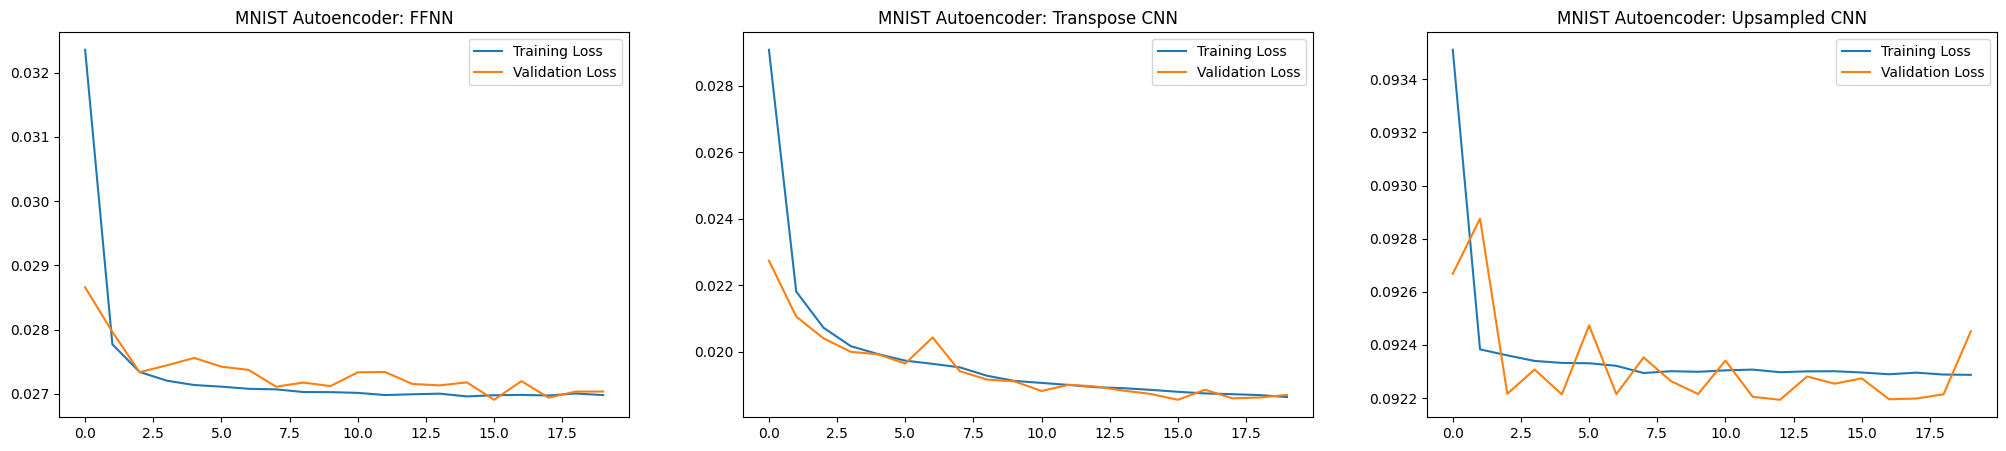

In [18]:
title=['FFNN','Transpose CNN','Upsampled CNN']
model_losses=[m1_loss,m2_loss,m3_loss]

fig=plt.figure(1,figsize=(25,5))
idx=1
for i in model_losses:
  ax=fig.add_subplot(1,3,idx)
  ax.plot(i['train'],label="Training Loss")
  ax.plot(i['valid'],label="Validation Loss")
  ax.set_title('MNIST Autoencoder: '+title[idx-1])
  idx+=1
  plt.legend();

## Testing Phase

In [21]:
def test(model, state='fully'):
    # obtain one batch of test images
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    if use_cuda and torch.cuda.is_available():
        images=images.cuda()
    if state=='fully':
        images = images.view(images.size(0), -1)

    # get sample outputs
    output = model(images)
    # prep images for display
    images = images.cpu().numpy()
    # output is resized into a batch of images
    output = output.view(batch_size, 1, 28, 28)
    # use detach when it's an output that requires_grad
    output = output.cpu().detach().numpy()


    # plot the first ten input images and then reconstructed images
    fig, axes = plt.subplots(nrows=2, ncols=10, sharex=True, sharey=True, figsize=(25,4))

    # input images on top row, reconstructions on bottom
    for images, row in zip([images, output], axes):
        for img, ax in zip(images, row):
            if state=='fully':
                img = img.reshape(1, 28, 28)
            ax.imshow(np.squeeze(img), cmap='gray')
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)


## FFNN Autoencoder

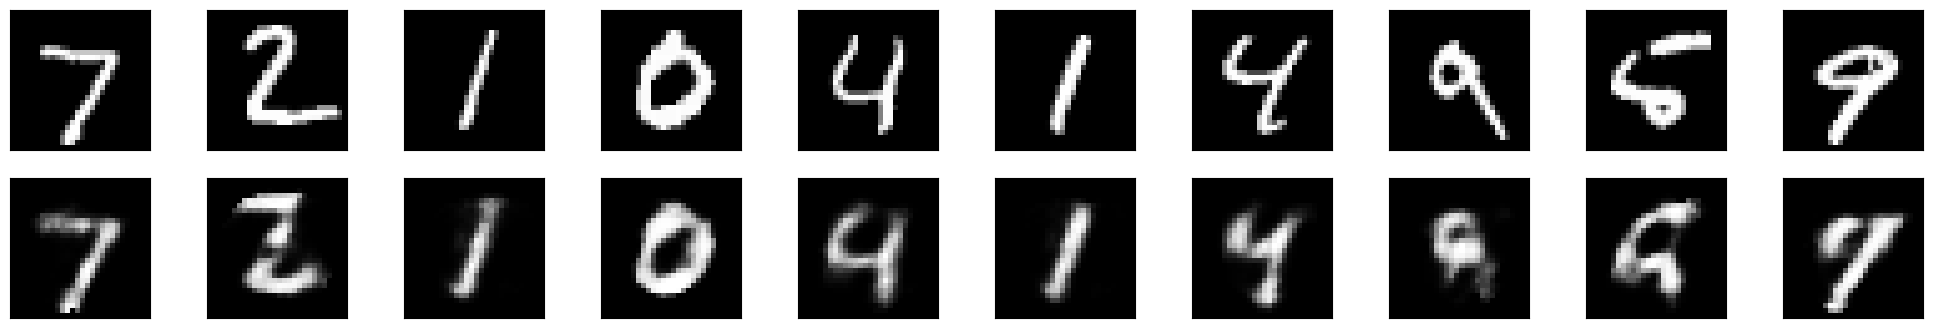

In [22]:
test(model_1)

## Transpose CNN Autoencoder

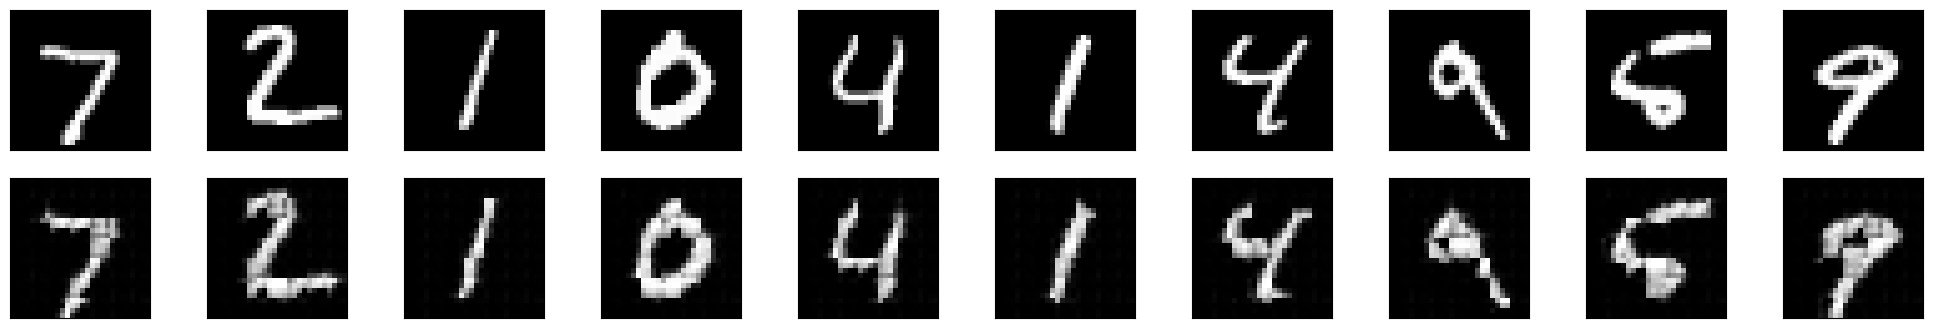

In [23]:
test(model_2,'conv')

## Upsampled CNN Autoencoder

/tmp/ipykernel_965/219568314.py:42: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')
/tmp/ipykernel_965/219568314.py:44: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')


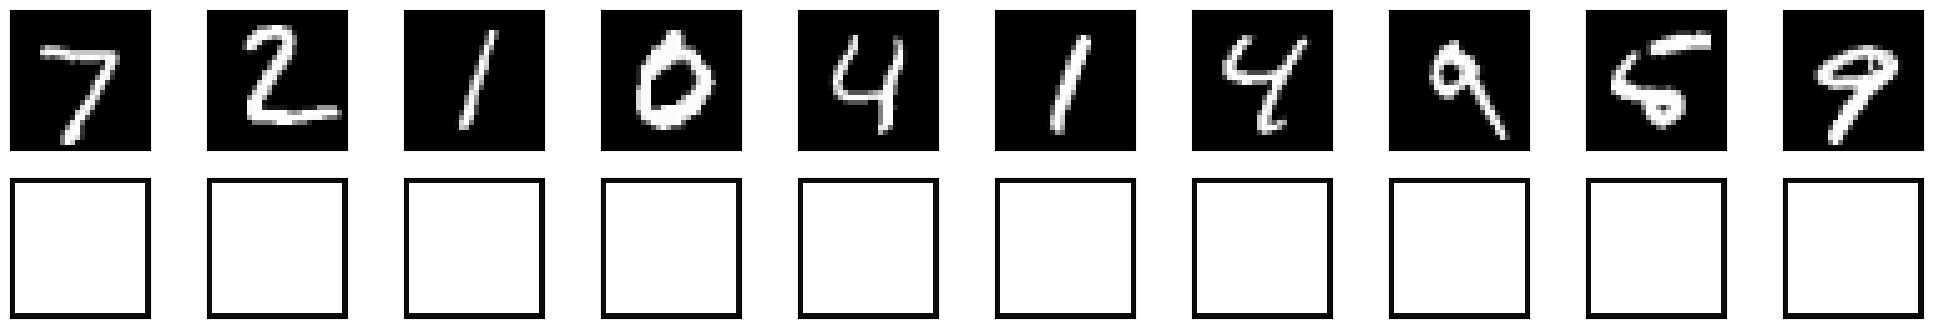

In [24]:
test(model_3,'conv')

# Student Task 1: Creating Noisy MNIST Images

## Objective

The objective of this task is to create noisy versions of the original MNIST images by adding Gaussian noise. These noisy images will be used as input for the denoising autoencoder, while the original clean images will serve as the target during training.

In [25]:
# ============================================================
# Student Task 1 : Creating Noisy MNIST Images
# ============================================================

import torch

# Noise intensity
noise_factor = 0.30

# Create noisy training images
train_images = train_data.data.float() / 255.0
train_images = train_images.unsqueeze(1)

train_noisy = train_images + noise_factor * torch.randn_like(train_images)
train_noisy = torch.clamp(train_noisy, 0., 1.)

# Create noisy testing images
test_images = test_data.data.float() / 255.0
test_images = test_images.unsqueeze(1)

test_noisy = test_images + noise_factor * torch.randn_like(test_images)
test_noisy = torch.clamp(test_noisy, 0., 1.)

print("Training Images Shape :", train_images.shape)
print("Noisy Training Images Shape :", train_noisy.shape)

print("Testing Images Shape :", test_images.shape)
print("Noisy Testing Images Shape :", test_noisy.shape)

Training Images Shape : torch.Size([60000, 1, 28, 28])
Noisy Training Images Shape : torch.Size([60000, 1, 28, 28])
Testing Images Shape : torch.Size([10000, 1, 28, 28])
Noisy Testing Images Shape : torch.Size([10000, 1, 28, 28])


## Visualizing Original and Noisy Images

The following images show the effect of adding Gaussian noise to the MNIST dataset. Although the digits become noisy, their overall structure is still visible, allowing the autoencoder to learn how to reconstruct the original clean images.

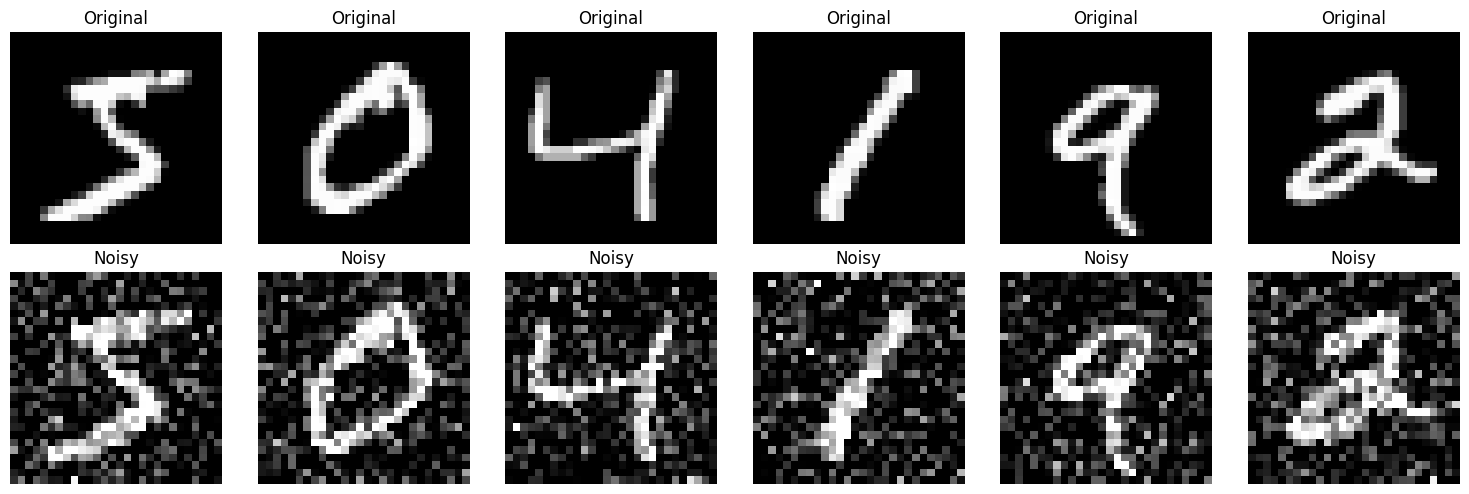

In [26]:
# ============================================================
# Display Original and Noisy Images
# ============================================================

import matplotlib.pyplot as plt

num_images = 6

plt.figure(figsize=(15,5))

# Original Images
for i in range(num_images):

    plt.subplot(2, num_images, i + 1)

    plt.imshow(train_images[i].squeeze(), cmap="gray")

    plt.title("Original")

    plt.axis("off")


# Noisy Images
for i in range(num_images):

    plt.subplot(2, num_images, num_images + i + 1)

    plt.imshow(train_noisy[i].squeeze(), cmap="gray")

    plt.title("Noisy")

    plt.axis("off")

plt.tight_layout()

plt.show()

## Observation

- Gaussian noise was successfully added to the MNIST images.
- The noisy images retain the digit structure while introducing random disturbances.
- These noisy images will be used as the input for the denoising autoencoder, whereas the original clean images will be used as the target output during training.

# Student Task 2: Building a Denoising Autoencoder

## Objective

The objective of this task is to design a convolutional denoising autoencoder that learns to remove Gaussian noise from MNIST images. The model takes noisy images as input and reconstructs the corresponding clean images.

In [27]:
# ============================================================
# Student Task 2 : Denoising Autoencoder
# ============================================================

import torch
import torch.nn as nn

class DenoisingAutoencoder(nn.Module):

    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(

            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2, 2)
        )

        # Decoder
        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):

        x = self.encoder(x)
        x = self.decoder(x)

        return x

In [28]:
# Create the model

denoising_model = DenoisingAutoencoder()

print(denoising_model)

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
)


In [29]:
# Move model to GPU (if available)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

denoising_model = denoising_model.to(device)

print("Using Device :", device)

Using Device : cuda


In [30]:
# Loss Function and Optimizer

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    denoising_model.parameters(),
    lr=0.001
)

print("Model compiled successfully.")

Model compiled successfully.


## Observation

- A convolutional denoising autoencoder was successfully created.
- The encoder extracts important image features while reducing the image dimensions.
- The decoder reconstructs the original clean image from the compressed representation.
- Mean Squared Error (MSE) is used as the loss function because the model predicts pixel values of the reconstructed image.

# Student Task 3: Training the Denoising Autoencoder

## Objective

The objective of this task is to train the denoising autoencoder using noisy MNIST images as input and the corresponding clean images as the target. The model learns to reconstruct clean images by minimizing the reconstruction error.

In [31]:
# ============================================================
# Student Task 3 : Prepare Dataset for Training
# ============================================================

from torch.utils.data import TensorDataset, DataLoader

# Create dataset
train_dataset = TensorDataset(train_noisy, train_images)

# DataLoader
denoise_train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

print("Training Samples :", len(train_dataset))

Training Samples : 60000


In [34]:
# ============================================================
# Student Task 3 : Train the Denoising Autoencoder
# ============================================================

num_epochs = 20

train_losses = []

for epoch in range(num_epochs):

    denoising_model.train()

    running_loss = 0.0

    for noisy_imgs, clean_imgs in denoise_train_loader:

        noisy_imgs = noisy_imgs.to(device)
        clean_imgs = clean_imgs.to(device)

        optimizer.zero_grad()

        outputs = denoising_model(noisy_imgs)

        loss = criterion(outputs, clean_imgs)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(denoise_train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.6f}")
# Training completed

print("Training completed successfully.")
# Final Training Loss

print(f"Final Training Loss : {train_losses[-1]:.6f}")

Epoch [1/20] Loss: 0.005767
Epoch [2/20] Loss: 0.005754
Epoch [3/20] Loss: 0.005749
Epoch [4/20] Loss: 0.005731
Epoch [5/20] Loss: 0.005722
Epoch [6/20] Loss: 0.005710
Epoch [7/20] Loss: 0.005699
Epoch [8/20] Loss: 0.005694
Epoch [9/20] Loss: 0.005685
Epoch [10/20] Loss: 0.005676
Epoch [11/20] Loss: 0.005669
Epoch [12/20] Loss: 0.005659
Epoch [13/20] Loss: 0.005655
Epoch [14/20] Loss: 0.005648
Epoch [15/20] Loss: 0.005635
Epoch [16/20] Loss: 0.005627
Epoch [17/20] Loss: 0.005623
Epoch [18/20] Loss: 0.005615
Epoch [19/20] Loss: 0.005612
Epoch [20/20] Loss: 0.005603
Training completed successfully.
Final Training Loss : 0.005603


## Observation

- The denoising autoencoder was successfully trained using noisy images as input and clean images as the target.
- The training loss decreased over successive epochs, indicating that the model learned to reconstruct cleaner images.
- The trained model can now be evaluated on unseen noisy test images.

# Student Task 4: Testing the Denoising Autoencoder

## Objective

The objective of this task is to evaluate the trained denoising autoencoder by comparing the original images, noisy images, and reconstructed (denoised) images. This helps in visually assessing the model's ability to remove noise while preserving the original digit structure.

In [35]:
# ============================================================
# Student Task 4 : Test the Denoising Autoencoder
# ============================================================

denoising_model.eval()

with torch.no_grad():

    noisy_test = test_noisy.to(device)

    denoised_images = denoising_model(noisy_test)

    denoised_images = denoised_images.cpu()

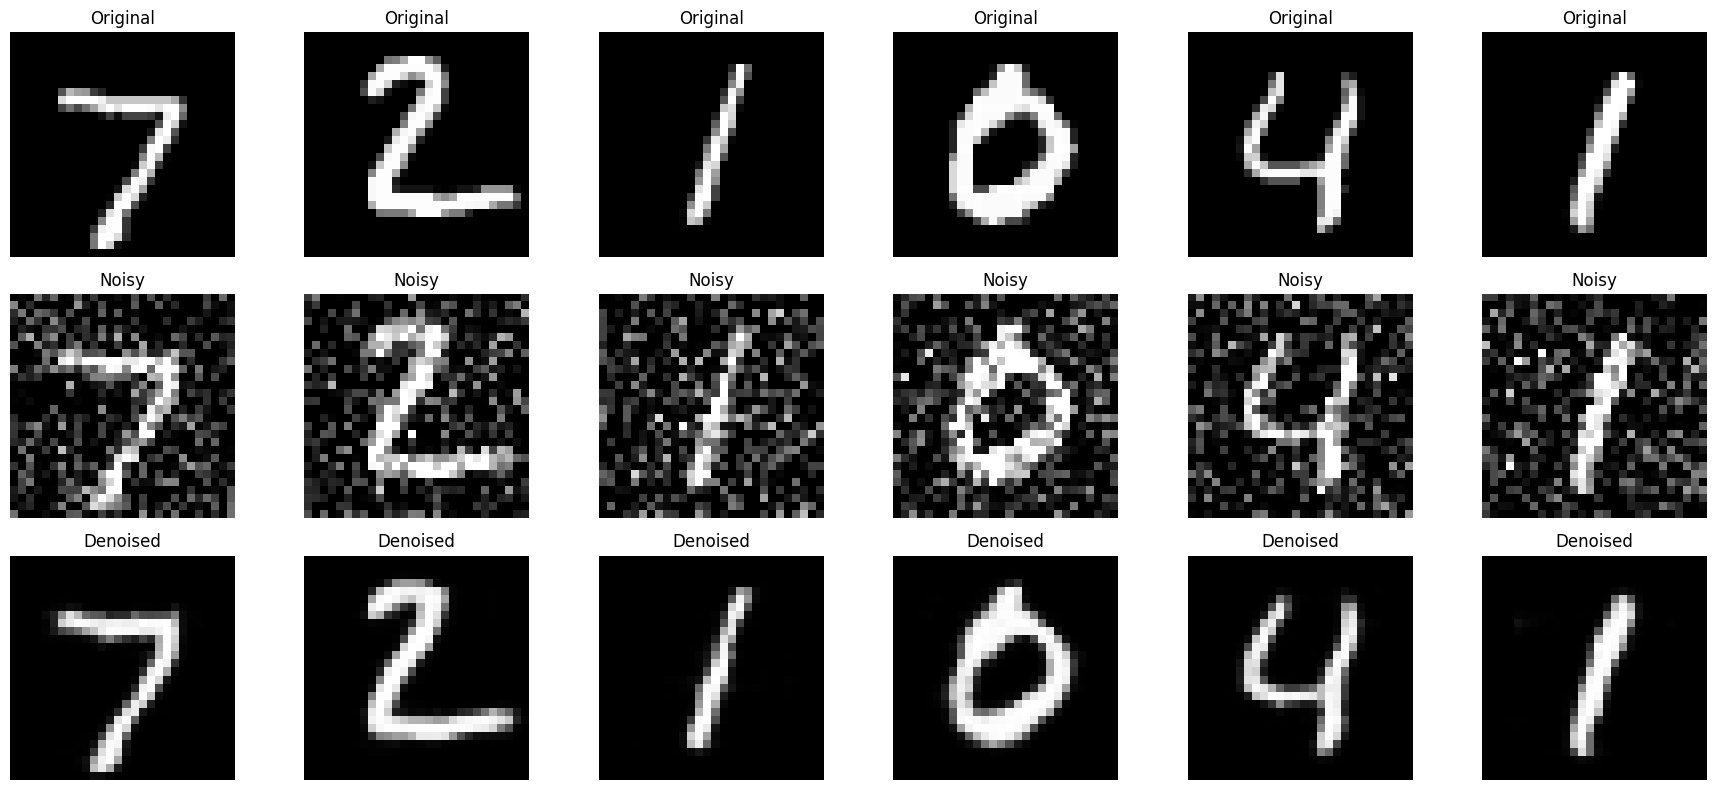

In [36]:
# ============================================================
# Display Original, Noisy and Denoised Images
# ============================================================

import matplotlib.pyplot as plt

num_images = 6

plt.figure(figsize=(18,8))

for i in range(num_images):

    # Original Image
    plt.subplot(3, num_images, i + 1)
    plt.imshow(test_images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy Image
    plt.subplot(3, num_images, num_images + i + 1)
    plt.imshow(test_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised Image
    plt.subplot(3, num_images, (2 * num_images) + i + 1)
    plt.imshow(denoised_images[i].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()

plt.show()

## Observation

- The first row shows the original clean MNIST images.
- The second row displays the corresponding noisy images after adding Gaussian noise.
- The third row shows the reconstructed images produced by the denoising autoencoder.
- The reconstructed images are noticeably cleaner than the noisy inputs, demonstrating that the model has successfully learned to reduce noise while preserving the digit features.

# Student Task 5: Training Loss Visualization

## Objective

The objective of this task is to visualize the training loss of the denoising autoencoder over multiple epochs. A decreasing loss indicates that the model is learning to reconstruct clean images from noisy inputs effectively.

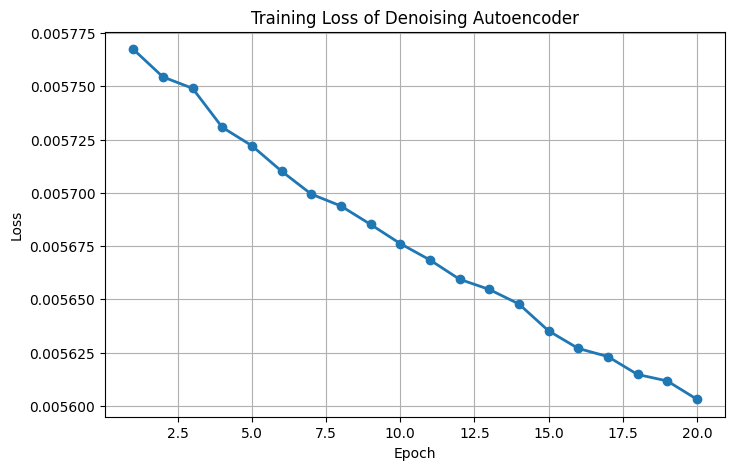

In [37]:
# ============================================================
# Student Task 5 : Plot Training Loss
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1, len(train_losses) + 1),
         train_losses,
         marker='o',
         linewidth=2)

plt.title("Training Loss of Denoising Autoencoder")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

## Observation

- The training loss decreases gradually as the number of epochs increases.
- A lower reconstruction loss indicates that the denoising autoencoder is learning to recover clean images from noisy inputs.
- The smooth decline in the loss curve suggests stable training without significant fluctuations.

# Student Task 6: Performance Comparison

## Objective

The objective of this task is to compare the original autoencoder models with the proposed denoising autoencoder. This comparison highlights the differences in architecture, input type, output type, and application.

In [38]:
# ============================================================
# Student Task 6 : Model Comparison
# ============================================================

import pandas as pd

comparison_df = pd.DataFrame({

    "Model": [
        "Fully Connected Autoencoder",
        "Transpose Convolution Autoencoder",
        "Upsampling Convolution Autoencoder",
        "Denoising Autoencoder"
    ],

    "Input": [
        "Clean Image",
        "Clean Image",
        "Clean Image",
        "Noisy Image"
    ],

    "Output": [
        "Reconstructed Image",
        "Reconstructed Image",
        "Reconstructed Image",
        "Denoised Image"
    ],

    "Main Purpose": [
        "Image Reconstruction",
        "Image Reconstruction",
        "Image Reconstruction",
        "Image Denoising"
    ]

})

comparison_df

,Model,Input,Output,Main Purpose
0,Fully Connected Autoencoder,Clean Image,Reconstructed Image,Image Reconstruction
1,Transpose Convolution Autoencoder,Clean Image,Reconstructed Image,Image Reconstruction
2,Upsampling Convolution Autoencoder,Clean Image,Reconstructed Image,Image Reconstruction
3,Denoising Autoencoder,Noisy Image,Denoised Image,Image Denoising


## Observation

- The original notebook focuses on reconstructing clean images using different autoencoder architectures.
- The proposed denoising autoencoder extends the original work by learning to remove Gaussian noise from images.
- Unlike the original models, the denoising autoencoder takes noisy images as input and reconstructs clean images as output.
- This enhancement demonstrates the practical application of autoencoders for image restoration tasks.

# Student Task 7: Final Observations

- Gaussian noise was successfully added to the MNIST images.
- A convolutional denoising autoencoder was designed and trained using noisy images as input and clean images as the target.
- The training loss decreased steadily, indicating effective learning.
- The reconstructed images were significantly cleaner than the noisy inputs while preserving the digit structure.
- The denoising autoencoder successfully extended the original notebook by performing image restoration in addition to image reconstruction.

# Conclusion

In this assignment, a denoising autoencoder was developed to remove Gaussian noise from MNIST images. A noisy version of the dataset was created, and the model was trained to reconstruct the corresponding clean images. The decreasing training loss and visual comparison of original, noisy, and denoised images demonstrate that the model successfully learned the denoising task. This implementation extends the original autoencoder notebook by showcasing a practical application of deep learning for image restoration.